# 2D TV denoising: method comparison

This notebook checks the current 2D transform-shrink TV methods in this repo:

1. one-pass Kamilov transform shrinkage,
2. Kamilov ISTA diagnostic experiment,
3. Kamilov FISTA diagnostic experiment,
4. MIRT POGM with gradient restart.

Unlike the 1D notebook, this notebook does not have a Condat-style exact 2D reference solver. The gamma sweep is therefore a diagnostic sweep on a synthetic image with known truth: the selected gamma is the best value for this image, noise level, lambda, and fixed iteration budget, not a universal step size.


In [1]:
import Pkg
Pkg.activate("docs")


## 2D shrinkage and gamma

The 2D transform produces two detail coefficient arrays, `dv` and `dh`. At each pixel, shrinkage is applied to the detail vector

$$
z_{i,j} = \begin{bmatrix} d_v[i,j] \\ d_h[i,j] \end{bmatrix}.
$$

The vector shrinkage operator is

$$
T(z_{i,j}; \tau) =
\begin{cases}
\left(1 - \dfrac{\tau}{\|z_{i,j}\|_2}\right) z_{i,j}, & \|z_{i,j}\|_2 > \tau, \\
0, & \|z_{i,j}\|_2 \le \tau.
\end{cases}
$$

For the one-pass 2D method, the current threshold is

$$
\tau = 2 \lambda \sqrt{2}.
$$

For ISTA/FISTA, the same shrinkage step is used inside a proximal-gradient iteration, so the threshold includes the step size:

$$
\tau_\gamma = 2 \gamma \lambda \sqrt{2}.
$$

Therefore the gamma sweep changes both the gradient step and the shrinkage threshold. Because this is an experimental transform-domain TV pipeline, the sweep below checks empirical behavior rather than proving an exact 2D TV solution.


In [2]:
using Random, LinearAlgebra, Printf, Plots, BenchmarkTools
using MIRT
using TVDenoising

function rmse(x, xref)
    return norm(x - xref) / sqrt(length(x))
end

function tv2_iso_value(x)
    total = 0.0
    rows, cols = axes(x, 1), axes(x, 2)
    @inbounds for j in first(cols):(last(cols)-1), i in first(rows):(last(rows)-1)
        dx = x[i + 1, j] - x[i, j]
        dy = x[i, j + 1] - x[i, j]
        total += hypot(dx, dy)
    end
    return total
end

function tv2_objective(x, y, λ)
    return 0.5 * sum(abs2, x .- y) + λ * tv2_iso_value(x)
end


In [3]:
Random.seed!(2026)

M, N = 96, 96
xtrue = zeros(Float64, M, N)
xtrue[18:78, 20:74] .= 0.7
xtrue[36:62, 42:88] .= 1.4
xtrue[12:32, 60:84] .= -0.4

y = xtrue + 0.25 * randn(M, N)
λ = 0.08

println("Noisy RMSE     = ", rmse(y, xtrue))
println("Noisy objective = ", tv2_objective(y, y, λ))


Noisy RMSE     = 0.24872577727892217
Noisy objective = 329.08284358716395


In [4]:
x_onepass = similar(y)
av = similar(y)
dv = similar(y)
ah = similar(y)
dh = similar(y)

tv2d_kamilov_onepass!(x_onepass, y, λ, av, dv, ah, dh)

println("One-pass RMSE     = ", rmse(x_onepass, xtrue))
println("One-pass objective = ", tv2_objective(x_onepass, y, λ))


One-pass RMSE     = 0.15442213621634499
One-pass objective = 238.875241234829


In [5]:
# Broad sweep plus a focused FISTA region found from a first pass.
gammas = sort(unique([
    0.2, 0.1, 0.05, 0.02, 0.01, 0.005, 0.002, 0.001,
    0.0008, 0.0006, 0.0005, 0.0004, 0.00038, 0.00035,
    0.00033, 0.00031, 0.00030, 0.00029, 0.00027,
    0.00025, 0.0002, 0.00015, 0.0001,
]); rev=true)

ista_maxiter = 1000
fista_maxiter = 1000
pogm_L = 6666.666666666667
pogm_maxiter = 1000

x_ista_by_gamma = Dict{Float64, Matrix{Float64}}()
x_fista_by_gamma = Dict{Float64, Matrix{Float64}}()
ista_rmse = Float64[]
fista_rmse = Float64[]
ista_obj = Float64[]
fista_obj = Float64[]

for γ in gammas
    xi = tv2d_kamilov_ista(y, λ; γ=γ, maxiter=ista_maxiter)
    xf = tv2d_kamilov_fista(y, λ; γ=γ, maxiter=fista_maxiter)

    x_ista_by_gamma[γ] = xi
    x_fista_by_gamma[γ] = xf

    push!(ista_rmse, rmse(xi, xtrue))
    push!(fista_rmse, rmse(xf, xtrue))
    push!(ista_obj, tv2_objective(xi, y, λ))
    push!(fista_obj, tv2_objective(xf, y, λ))
end

best_ista_idx = argmin(ista_rmse)
best_fista_idx = argmin(fista_rmse)
best_ista_γ = gammas[best_ista_idx]
best_fista_γ = gammas[best_fista_idx]

@printf("Best ISTA  gamma by RMSE = %.6g, RMSE = %.6f, objective = %.6f
",
        best_ista_γ, ista_rmse[best_ista_idx], ista_obj[best_ista_idx])
@printf("Best FISTA gamma by RMSE = %.6g, RMSE = %.6f, objective = %.6f
",
        best_fista_γ, fista_rmse[best_fista_idx], fista_obj[best_fista_idx])

x_pogm = tv2d_kamilov_pogm(y, λ; L=pogm_L, maxiter=pogm_maxiter)
pogm_rmse = rmse(x_pogm, xtrue)
pogm_obj = tv2_objective(x_pogm, y, λ)
@printf("MIRT POGM by RMSE        = L %.6g, RMSE = %.6f, objective = %.6f, maxiter = %d\n",
        pogm_L, pogm_rmse, pogm_obj, pogm_maxiter)


Best ISTA  gamma by RMSE = 0.01, RMSE = 0.132899, objective = 229.367310
Best FISTA gamma by RMSE = 0.00015, RMSE = 0.130233, objective = 229.469322
MIRT POGM by RMSE        = L 6666.67, RMSE = 0.132895, objective = 229.402906, maxiter = 1000


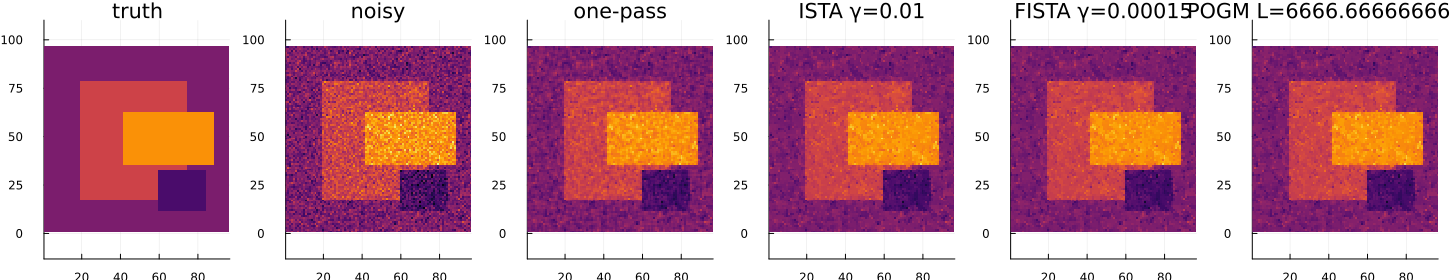

In [6]:
mkpath("figures")

x_ista_best = x_ista_by_gamma[best_ista_γ]
x_fista_best = x_fista_by_gamma[best_fista_γ]

clims = extrema(vcat(vec(xtrue), vec(y), vec(x_onepass), vec(x_ista_best), vec(x_fista_best), vec(x_pogm)))

p1 = heatmap(xtrue; title="truth", aspect_ratio=:equal, colorbar=false, clims=clims)
p2 = heatmap(y; title="noisy", aspect_ratio=:equal, colorbar=false, clims=clims)
p3 = heatmap(x_onepass; title="one-pass", aspect_ratio=:equal, colorbar=false, clims=clims)
p4 = heatmap(x_ista_best; title="ISTA γ=$(best_ista_γ)", aspect_ratio=:equal, colorbar=false, clims=clims)
p5 = heatmap(x_fista_best; title="FISTA γ=$(best_fista_γ)", aspect_ratio=:equal, colorbar=false, clims=clims)
p6 = heatmap(x_pogm; title="POGM L=$(pogm_L)", aspect_ratio=:equal, colorbar=false, clims=clims)

p_results = plot(p1, p2, p3, p4, p5, p6; layout=(1, 6), size=(1450, 280))
savefig(p_results, "figures/main2d_results.png")
p_results


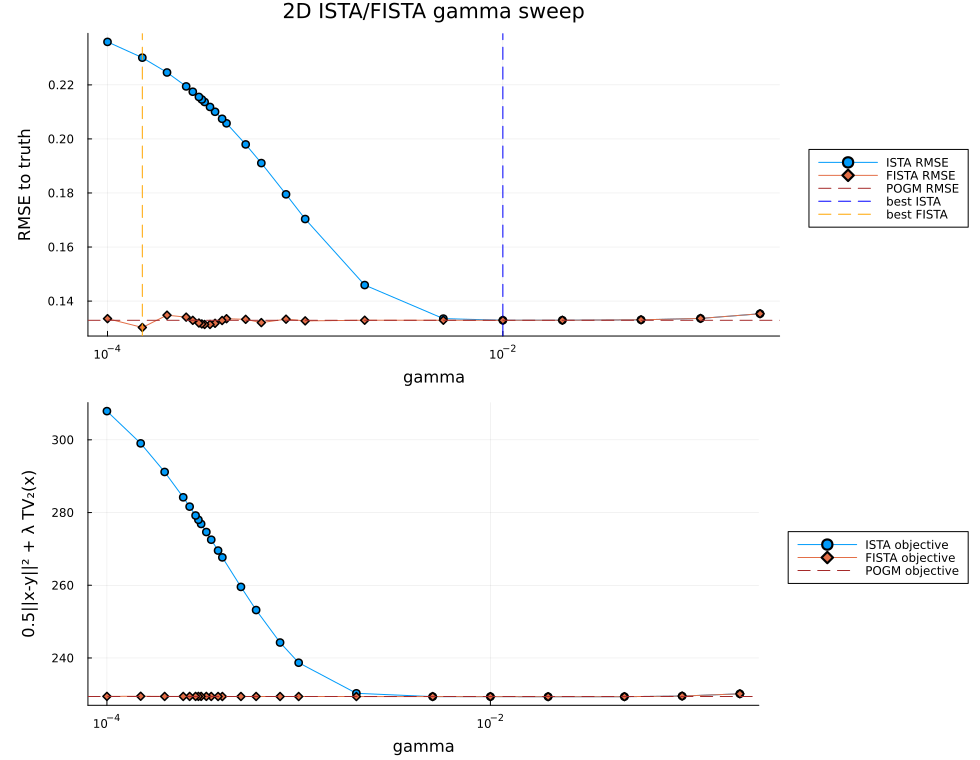

In [7]:
p_rmse = plot(
    gammas, ista_rmse;
    xscale=:log10,
    marker=:circle,
    label="ISTA RMSE",
    xlabel="gamma",
    ylabel="RMSE to truth",
    title="2D ISTA/FISTA gamma sweep",
    legend=:outerright,
)
plot!(p_rmse, gammas, fista_rmse; marker=:diamond, label="FISTA RMSE")
hline!(p_rmse, [pogm_rmse]; label="POGM RMSE", color=:brown, linestyle=:dash)
vline!(p_rmse, [best_ista_γ]; label="best ISTA", color=:blue, linestyle=:dash)
vline!(p_rmse, [best_fista_γ]; label="best FISTA", color=:orange, linestyle=:dash)

p_obj = plot(
    gammas, ista_obj;
    xscale=:log10,
    marker=:circle,
    label="ISTA objective",
    xlabel="gamma",
    ylabel="0.5||x-y||² + λ TV₂(x)",
    legend=:outerright,
)
plot!(p_obj, gammas, fista_obj; marker=:diamond, label="FISTA objective")
hline!(p_obj, [pogm_obj]; label="POGM objective", color=:brown, linestyle=:dash)

p_sweep = plot(p_rmse, p_obj; layout=(2, 1), size=(980, 760), left_margin=6Plots.mm)
savefig(p_sweep, "figures/main2d_gamma_sweep.png")
p_sweep


## ISTA/FISTA benchmark

This benchmark measures implementation cost for fixed iteration counts using preallocated workspaces. It is not a convergence-to-tolerance benchmark. The FISTA benchmark uses the gamma selected by the sweep above and fewer iterations so ISTA and FISTA are compared with the same iteration budget.


In [8]:
bench_ista_iters = 1000
bench_fista_iters = 1000

x_ista_b = similar(y)
av_ista_b = similar(y)
dv_ista_b = similar(y)
ah_ista_b = similar(y)
dh_ista_b = similar(y)
z_ista_b = similar(y)
xprev_ista_b = similar(y)

x_fista_b = similar(y)
av_fista_b = similar(y)
dv_fista_b = similar(y)
ah_fista_b = similar(y)
dh_fista_b = similar(y)
z_fista_b = similar(y)
xprev_fista_b = similar(y)
q_fista_b = similar(y)
qprev_fista_b = similar(y)
x_pogm_b = similar(y)

x_onepass_b = similar(y)
av_onepass_b = similar(y)
dv_onepass_b = similar(y)
ah_onepass_b = similar(y)
dh_onepass_b = similar(y)

bench_onepass = @benchmark tv2d_kamilov_onepass!(
    $x_onepass_b, $y, $λ, $av_onepass_b, $dv_onepass_b, $ah_onepass_b, $dh_onepass_b,
) samples=20 evals=1

bench_ista = @benchmark tv2d_kamilov_ista!(
    $x_ista_b, $y, $λ, $av_ista_b, $dv_ista_b, $ah_ista_b, $dh_ista_b, $z_ista_b, $xprev_ista_b;
    γ=$best_ista_γ, maxiter=$bench_ista_iters,
) samples=10 evals=1

bench_fista = @benchmark tv2d_kamilov_fista!(
    $x_fista_b, $y, $λ, $av_fista_b, $dv_fista_b, $ah_fista_b, $dh_fista_b,
    $z_fista_b, $xprev_fista_b, $q_fista_b, $qprev_fista_b;
    γ=$best_fista_γ, maxiter=$bench_fista_iters,
) samples=10 evals=1
bench_pogm = @benchmark tv2d_kamilov_pogm!(
    $x_pogm_b, $y, $λ;
    L=$pogm_L, maxiter=$pogm_maxiter,
) samples=10 evals=1

function bench_row(name, b)
    t_ms = median(b).time / 1e6
    mem = median(b).memory
    allocs = median(b).allocs
    @printf("%-8s  median time = %.3f ms, memory = %d bytes, allocations = %d
",
            name, t_ms, mem, allocs)
    return (method=name, median_ms=t_ms, memory_bytes=mem, allocations=allocs)
end

bench_results = [
    bench_row("onepass", bench_onepass),
    bench_row("ISTA", bench_ista),
    bench_row("FISTA", bench_fista),
    bench_row("POGM", bench_pogm),
]


onepass   median time = 0.125 ms, memory = 0 bytes, allocations = 0
ISTA      median time = 94.031 ms, memory = 0 bytes, allocations = 0
FISTA     median time = 82.185 ms, memory = 0 bytes, allocations = 0
POGM      median time = 386.118 ms, memory = 2132510320 bytes, allocations = 92014


In [9]:
open("figures/main2d_results.txt", "w") do io
    println(io, "2D TV denoising diagnostics")
    println(io, "N = $(M)x$(N), lambda = $(λ)")
    println(io, "Noisy RMSE = $(rmse(y, xtrue))")
    println(io, "One-pass RMSE = $(rmse(x_onepass, xtrue))")
    println(io, "Best ISTA gamma = $(best_ista_γ), RMSE = $(ista_rmse[best_ista_idx]), maxiter = $(ista_maxiter)")
    println(io, "Best FISTA gamma = $(best_fista_γ), RMSE = $(fista_rmse[best_fista_idx]), maxiter = $(fista_maxiter)")
    println(io, "MIRT POGM L = $(pogm_L), RMSE = $(pogm_rmse), maxiter = $(pogm_maxiter)")
    println(io)
    println(io, "Benchmark median time and memory")
    for row in bench_results
        println(io, row)
    end
end

read("figures/main2d_results.txt", String)


'2D TV denoising diagnostics\nN = 96x96, lambda = 0.08\nNoisy RMSE = 0.24872577727892217\nOne-pass RMSE = 0.15442213621634499\nBest ISTA gamma = 0.01, RMSE = 0.1328989749838951, maxiter = 1000\nBest FISTA gamma = 0.00015, RMSE = 0.13023307323610872, maxiter = 1000\nMIRT POGM L = 6666.666666666667, RMSE = 0.13289538783382054, maxiter = 1000\n\nBenchmark median time and memory\n(method = "onepass", median_ms = 0.1251665, memory_bytes = 0, allocations = 0)\n(method = "ISTA", median_ms = 94.0314165, memory_bytes = 0, allocations = 0)\n(method = "FISTA", median_ms = 82.1846875, memory_bytes = 0, allocations = 0)\n(method = "POGM", median_ms = 386.117563, memory_bytes = 2132510320, allocations = 92014)\n'